Imports

In [1]:
%pip install -U imbalanced-learn


  Attempting uninstall: sklearn-compat

    Found existing installation: sklearn-compat 0.1.5

    Uninstalling sklearn-compat-0.1.5:

      Successfully uninstalled sklearn-compat-0.1.5

   ---------------------------------------- 0/2 [sklearn-compat]
  Attempting uninstall: imbalanced-learn
   ---------------------------------------- 0/2 [sklearn-compat]
    Found existing installation: imbalanced-learn 0.14.1
   ---------------------------------------- 0/2 [sklearn-compat]
    Uninstalling imbalanced-learn-0.14.1:
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
      Successfully uninstalled imbalanced-learn-0.14.1
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ------------------

In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix
)

from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

Load Dataset

In [3]:
DATA_PATH = "../data/okcupid_cleaned_redflags.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(700, 36)


,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,negativity,sarcasm_cynicism,substance_risk,incomplete_profile,controlling_behavior,emotional_manipulation,entitlement_superiority,poor_conflict_resolution,main_character_syndrome,dismissive
0,26,single,m,straight,average,anything,socially,never,graduated from high school,white,...,0,1,0,0,0,0,0,0,0,0
1,37,single,m,gay,athletic,NaN,socially,never,NaN,white,...,0,0,0,0,0,0,0,0,0,0
2,30,single,m,straight,fit,anything,socially,never,working on masters program,asian,...,0,1,0,0,0,0,0,0,0,0
3,26,single,m,straight,average,mostly anything,socially,NaN,graduated from college/university,"middle eastern, other",...,0,1,1,0,0,0,0,0,0,0
4,33,single,m,straight,average,strictly anything,often,NaN,graduated from college/university,white,...,1,1,1,0,0,0,0,0,0,1


Define Features

In [4]:
tabular_features = [
    "age",
    "status",
    "sex",
    "orientation",
    "body_type",
    "diet",
    "drinks",
    "drugs",
    "education",
    "ethnicity",
    "height",
    "income",
    "job",
    "offspring",
    "pets",
    "religion",
    "sign",
    "smokes"
]

label_columns = [
    "aggressive_tone",
    "hookup_focus",
    "negativity",
    "sarcasm_cynicism",
    "substance_risk",
    "incomplete_profile",
    "controlling_behavior",
    "emotional_manipulation",
    "entitlement_superiority",
    "poor_conflict_resolution",
    "main_character_syndrome",
    "dismissive",
]

Prepare X and Y

In [5]:
X = df[tabular_features]

y = df[label_columns]

print("Input Shape:", X.shape)

print("Target Shape:", y.shape)

Input Shape: (700, 18)
Target Shape: (700, 12)


Label Distribution

sarcasm_cynicism            303
substance_risk              289
dismissive                  102
aggressive_tone              61
negativity                   57
incomplete_profile           29
controlling_behavior         12
hookup_focus                 11
poor_conflict_resolution      7
main_character_syndrome       4
entitlement_superiority       3
emotional_manipulation        0
dtype: int64


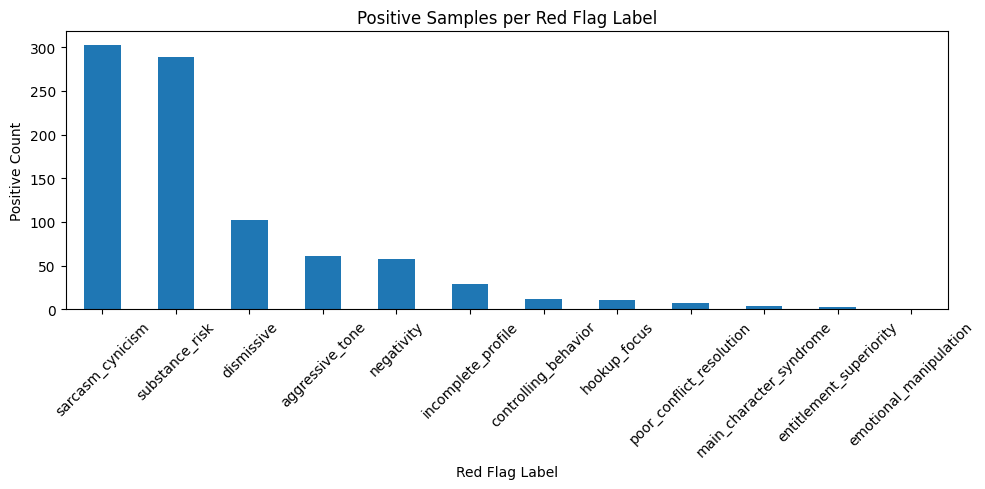

In [6]:
label_counts = y.sum().sort_values(ascending=False)

print(label_counts)

plt.figure(figsize=(10, 5))

label_counts.plot(kind="bar")

plt.title("Positive Samples per Red Flag Label")

plt.xlabel("Red Flag Label")

plt.ylabel("Positive Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (560, 18)
X_test: (140, 18)
y_train: (560, 12)
y_test: (140, 12)


Numeric and categoriack features

In [8]:
numeric_features = [
    "age",
    "height",
    "income"
]

categorical_features = [
    col for col in tabular_features
    if col not in numeric_features
]

print(numeric_features)

print(categorical_features)

['age', 'height', 'income']
['status', 'sex', 'orientation', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'ethnicity', 'job', 'offspring', 'pets', 'religion', 'sign', 'smokes']


numeric transformer

In [9]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical transformer

In [10]:
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

column transformer

In [11]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

tranform datesset

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)

print(X_test_processed.shape)

(560, 237)
(140, 237)


initailize containers

In [13]:
models = {}

predictions = pd.DataFrame()

confusion_summary = []

tarin SMOTE models

In [14]:
from collections import Counter
from sklearn.dummy import DummyClassifier

for label in label_columns:

    print(f"\nTraining Model For: {label}")

    y_train_label = y_train[label].astype(int)
    y_test_label = y_test[label].astype(int)

    class_counts = Counter(y_train_label)
    print("Original Class Distribution:", class_counts)

    # SMOTE cannot work if the target only has one class.
    # This can happen for very rare labels such as emotional_manipulation.
    if len(class_counts) < 2:
        print(f"Skipping SMOTE for {label}: only one class found.")

        classifier = DummyClassifier(strategy="most_frequent")
        classifier.fit(X_train_processed, y_train_label)

        y_pred = classifier.predict(X_test_processed)

    else:
        minority_count = min(class_counts.values())

        # Default SMOTE uses k_neighbors=5, which fails when the minority class is too small.
        if minority_count < 2:
            print(f"Skipping SMOTE for {label}: minority class has fewer than 2 samples.")

            X_resampled = X_train_processed
            y_resampled = y_train_label

        else:
            k_neighbors = min(5, minority_count - 1)

            smote = SMOTE(
                random_state=42,
                k_neighbors=k_neighbors
            )

            X_resampled, y_resampled = smote.fit_resample(
                X_train_processed,
                y_train_label
            )

        print("Original Samples:", len(y_train_label))
        print("Resampled Samples:", len(y_resampled))

        classifier = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )

        classifier.fit(X_resampled, y_resampled)

        y_pred = classifier.predict(X_test_processed)

    predictions[label] = y_pred
    models[label] = classifier

    print(
        classification_report(
            y_test_label,
            y_pred,
            labels=[0, 1],
            zero_division=0
        )
    )

    # Simple confusion matrix - force 2x2 output even when one class is missing
    tn, fp, fn, tp = confusion_matrix(
        y_test_label,
        y_pred,
        labels=[0, 1]
    ).ravel()

    confusion_summary.append({
        "label": label,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

# View results
confusion_df = pd.DataFrame(confusion_summary)
print("\n" + "="*50)
print("Confusion Matrix Summary:")
print(confusion_df)



Training Model For: aggressive_tone
Original Class Distribution: Counter({0: 511, 1: 49})
Original Samples: 560
Resampled Samples: 1022
              precision    recall  f1-score   support

           0       0.91      1.00      0.96       128
           1       0.00      0.00      0.00        12

    accuracy                           0.91       140
   macro avg       0.46      0.50      0.48       140
weighted avg       0.84      0.91      0.87       140


Training Model For: hookup_focus
Original Class Distribution: Counter({0: 550, 1: 10})
Original Samples: 560
Resampled Samples: 1100
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       139
           1       0.00      0.00      0.00         1

    accuracy                           0.99       140
   macro avg       0.50      0.50      0.50       140
weighted avg       0.99      0.99      0.99       140


Training Model For: negativity
Original Class Distribution: Counter({0: 51

overall evalutaion metrics

In [15]:
micro_precision = precision_score(
    y_test,
    predictions,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    y_test,
    predictions,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    y_test,
    predictions,
    average="micro",
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

hamming = hamming_loss(
    y_test,
    predictions
)

overall_metrics = pd.DataFrame({
    "Metric": [
        "Micro Precision",
        "Micro Recall",
        "Micro F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Hamming Loss"
    ],
    "Score": [
        micro_precision,
        micro_recall,
        micro_f1,
        macro_precision,
        macro_recall,
        macro_f1,
        hamming
    ]
})

overall_metrics

,Metric,Score
0,Micro Precision,0.730769
1,Micro Recall,0.339286
2,Micro F1,0.463415
3,Macro Precision,0.116088
4,Macro Recall,0.077570
5,Macro F1,0.092619
6,Hamming Loss,0.078571


classification report

In [16]:
report_dict = classification_report(
    y_test,
    predictions,
    target_names=label_columns,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

per_label_report = report_df.loc[
    label_columns,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

per_label_report

,precision,recall,f1-score,support
aggressive_tone,0.000000,0.000000,0.000000,12.0
hookup_focus,0.000000,0.000000,0.000000,1.0
negativity,0.000000,0.000000,0.000000,9.0
sarcasm_cynicism,0.437500,0.237288,0.307692,59.0
substance_risk,0.955556,0.693548,0.803738,62.0
incomplete_profile,0.000000,0.000000,0.000000,7.0
controlling_behavior,0.000000,0.000000,0.000000,1.0
emotional_manipulation,0.000000,0.000000,0.000000,0.0
entitlement_superiority,0.000000,0.000000,0.000000,1.0
poor_conflict_resolution,0.000000,0.000000,0.000000,1.0


plot f1 score

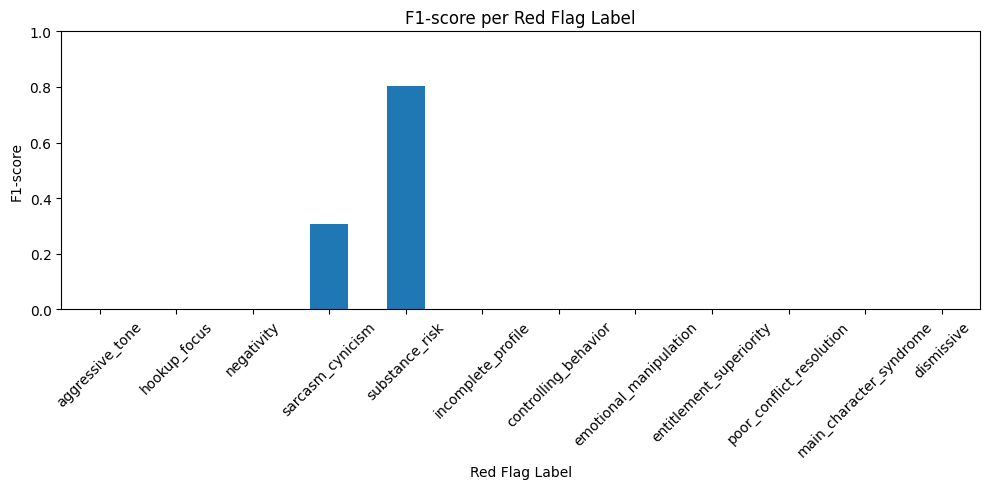

In [17]:
plt.figure(figsize=(10, 5))

per_label_report["f1-score"].plot(kind="bar")

plt.title("F1-score per Red Flag Label")

plt.xlabel("Red Flag Label")

plt.ylabel("F1-score")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

confusion summary

In [18]:
confusion_summary_df = pd.DataFrame(confusion_summary)

confusion_summary_df

,label,true_negative,false_positive,false_negative,true_positive
0,aggressive_tone,128,0,12,0
1,hookup_focus,139,0,1,0
2,negativity,130,1,9,0
3,sarcasm_cynicism,63,18,45,14
4,substance_risk,76,2,19,43
5,incomplete_profile,133,0,7,0
6,controlling_behavior,139,0,1,0
7,emotional_manipulation,140,0,0,0
8,entitlement_superiority,139,0,1,0
9,poor_conflict_resolution,139,0,1,0


feature importance

In [19]:
feature_names = preprocessor.get_feature_names_out()

sample_model = models["substance_risk"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": sample_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
41,cat__drugs_never,0.072604
37,cat__drinks_often,0.061390
43,cat__drugs_sometimes,0.058611
0,num__age,0.045204
1,num__height,0.041776
39,cat__drinks_socially,0.041586
232,cat__smokes_no,0.041261
233,cat__smokes_sometimes,0.021894
236,cat__smokes_yes,0.017161
102,cat__ethnicity_white,0.016897


plot feature importance

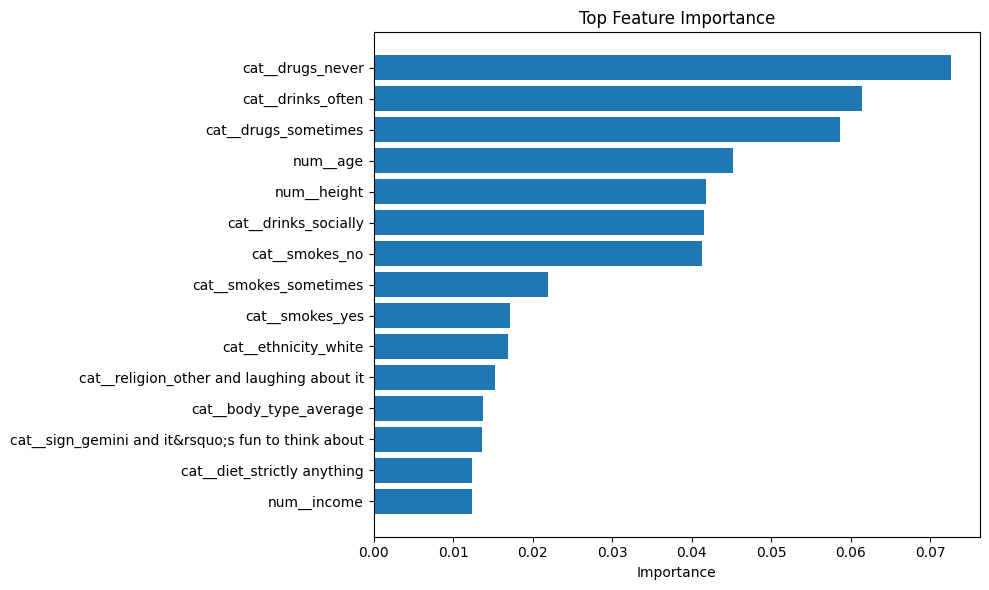

In [20]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

save models

In [21]:
joblib.dump(
    models,
    "../models/tabular_rf_smote_models.pkl"
)

joblib.dump(
    preprocessor,
    "../models/tabular_preprocessor.pkl"
)

print("Tabular SMOTE Models Saved Successfully")

Tabular SMOTE Models Saved Successfully


save reports

In [22]:
per_label_report.to_csv(
    "../reports/tabular_per_label_report.csv"
)

overall_metrics.to_csv(
    "../reports/tabular_overall_metrics.csv",
    index=False
)

confusion_summary_df.to_csv(
    "../reports/tabular_confusion_summary.csv",
    index=False
)

print("Evaluation Reports Saved Successfully")

Evaluation Reports Saved Successfully


inference function

In [23]:
def run_tabular_inference(profile_data):

    models = joblib.load(
        "../models/tabular_rf_smote_models.pkl"
    )

    preprocessor = joblib.load(
        "../models/tabular_preprocessor.pkl"
    )

    input_df = pd.DataFrame([profile_data])

    processed_input = preprocessor.transform(input_df)

    results = {}

    detected_flags = []

    for label, model in models.items():

        probability_output = model.predict_proba(
            processed_input
        )[0]

        # Some fallback models only know class 0.
        # In that case, the probability of class 1 should safely be 0.0.
        if 1 in model.classes_:
            positive_index = list(model.classes_).index(1)
            probability = probability_output[positive_index]
        else:
            probability = 0.0

        prediction = int(probability >= 0.5)

        results[label] = {
            "probability": round(float(probability), 4),
            "predicted": prediction
        }

        if prediction == 1:
            detected_flags.append(label)

    return {
        "detected_flags": detected_flags,
        "label_scores": results
    }


sample inference

In [24]:
sample_profile = {
    "age": 24,
    "status": "single",
    "sex": "m",
    "orientation": "straight",
    "body_type": "fit",
    "diet": "anything",
    "drinks": "often",
    "drugs": "sometimes",
    "education": "working on college",
    "ethnicity": "asian",
    "height": 175.0,
    "income": -1,
    "job": "student",
    "offspring": "doesn't have kids",
    "pets": "likes dogs",
    "religion": "agnosticism",
    "sign": "leo",
    "smokes": "yes"
}

results = run_tabular_inference(sample_profile)

results

{'detected_flags': ['substance_risk'],
 'label_scores': {'aggressive_tone': {'probability': 0.17, 'predicted': 0},
  'hookup_focus': {'probability': 0.045, 'predicted': 0},
  'negativity': {'probability': 0.235, 'predicted': 0},
  'sarcasm_cynicism': {'probability': 0.265, 'predicted': 0},
  'substance_risk': {'probability': 0.92, 'predicted': 1},
  'incomplete_profile': {'probability': 0.045, 'predicted': 0},
  'controlling_behavior': {'probability': 0.02, 'predicted': 0},
  'emotional_manipulation': {'probability': 0.0, 'predicted': 0},
  'entitlement_superiority': {'probability': 0.0, 'predicted': 0},
  'poor_conflict_resolution': {'probability': 0.005, 'predicted': 0},
  'main_character_syndrome': {'probability': 0.0, 'predicted': 0},
  'dismissive': {'probability': 0.21, 'predicted': 0}}}